In [ ]:
print("Afifa Qureshi , 231A061")
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

# Combine train and test
df = pd.concat(
    [
        dataset["train"].to_pandas(),
        dataset["test"].to_pandas()
    ],
    ignore_index=True
)



Afifa Qureshi , 231A061


In [ ]:
print("Afifa Qureshi , 231A061")
# Rename target column
df = df.rename(columns={"label": "labels"})

print(df.shape)
print(df.columns)
print(df["labels"].value_counts())

Afifa Qureshi , 231A061
(50000, 2)
Index(['text', 'labels'], dtype='object')
labels
0    25000
1    25000
Name: count, dtype: int64


In [ ]:
print("Afifa Qureshi , 231A061")
df['labels'].count()

Afifa Qureshi , 231A061


np.int64(50000)

In [ ]:
print("Afifa Qureshi , 231A061")
df.head()

Afifa Qureshi , 231A061


,text,labels
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
print("Afifa Qureshi , 231A061")
# ---------------------------------------------------------
# 2. CHECK MISSING VALUES AND DUPLICATES
# ---------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


# ---------------------------------------------------------
# 3. BASIC TEXT STATISTICS
# ---------------------------------------------------------

# Using "text" instead of the non-existent "review" column
df["char_count"] = df["text"].astype(str).apply(len)

df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

df["unique_word_count"] = df["text"].astype(str).apply(
    lambda x: len(set(x.lower().split()))
)
df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: sum(len(w) for w in x.split()) /
              max(len(x.split()), 1)
)

print("\nText Statistics:")
print(
    df[
        [
            "char_count",
            "word_count",
            "unique_word_count",
            "avg_word_length"
        ]
    ].describe()
)

Afifa Qureshi , 231A061

Missing values:
text                 0
labels               0
char_count           0
word_count           0
unique_word_count    0
avg_word_length      0
dtype: int64

Number of duplicate rows:
418

Text Statistics:
         char_count    word_count  unique_word_count  avg_word_length
count  50000.000000  50000.000000       50000.000000     50000.000000
mean    1309.431020    231.156940         148.049780         4.640676
std      989.728014    171.343997          88.837364         0.340731
min       32.000000      4.000000           4.000000         1.239865
25%      699.000000    126.000000          91.000000         4.417904
50%      970.000000    173.000000         120.000000         4.627006
75%     1590.250000    280.000000         180.000000         4.847458
max    13704.000000   2470.000000        1092.000000        12.290909


In [ ]:
print("Afifa Qureshi , 231A061")
import re

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Using "text" instead of the non-existent "review" column
df["clean_text"] = df["text"].astype(str).apply(clean_text)
print("\nOriginal Review:")
print(df["text"].iloc[0][:500])

print("\nCleaned Review:")
print(df["clean_text"].iloc[0][:500])

Afifa Qureshi , 231A061

Original Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Cleaned Review:
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in par

Afifa Qureshi , 231A061


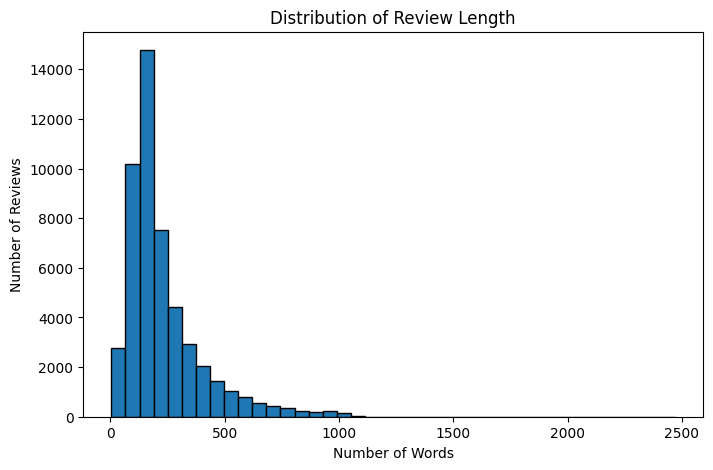

Total number of words: 11709196
Vocabulary size: 99420


In [ ]:
print("Afifa Qureshi , 231A061")
import matplotlib.pyplot as plt

# Ensure word_count and clean_text exist in df
if "word_count" not in df.columns:
    df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

if "clean_text" not in df.columns:
    import re
    def clean_text(text):
        text = text.lower()
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text
    df["clean_text"] = df["text"].astype(str).apply(clean_text)

# ---------------------------------------------------------
# 5. DOCUMENT LENGTH DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=40, edgecolor="black")

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")

plt.show()


# ---------------------------------------------------------
# ---------------------------------------------------------
# 6. CREATE WORD LIST
# ---------------------------------------------------------

all_words = " ".join(df["clean_text"]).split()

print("Total number of words:", len(all_words))
print("Vocabulary size:", len(set(all_words)))

Afifa Qureshi , 231A061


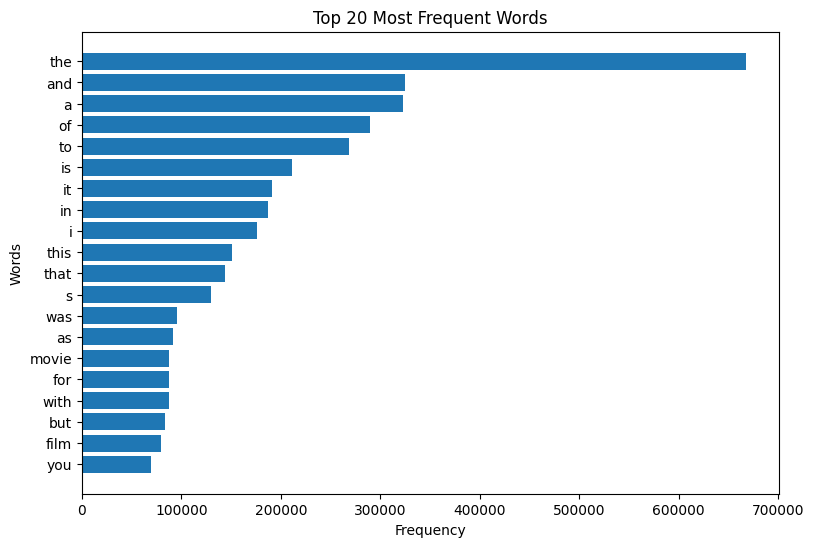

In [ ]:
print("Afifa Qureshi , 231A061")
from collections import Counter
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 7. MOST FREQUENT WORDS
# ---------------------------------------------------------

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(9, 6))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")

plt.show()

Afifa Qureshi , 231A061


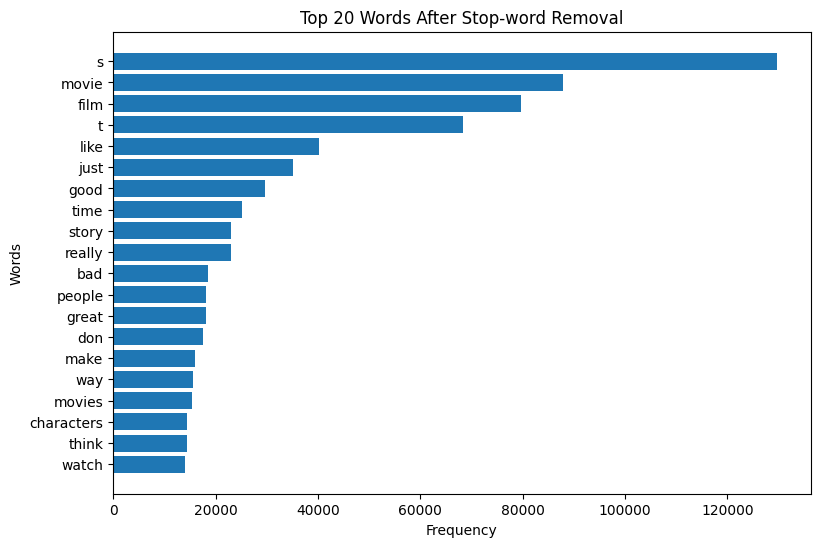

In [ ]:
print("Afifa Qureshi , 231A061")
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# ---------------------------------------------------------
# 8. REMOVE STOP WORDS
# ---------------------------------------------------------

vectorizer = CountVectorizer(
    stop_words="english"
)

# Fixed: Changed "clean_review" to "clean_text"
vectorizer.fit(df["clean_text"])

stop_words = vectorizer.get_stop_words()

filtered_words = [
    word for word in all_words
    if word not in stop_words
]

filtered_freq = Counter(filtered_words)

top_filtered = filtered_freq.most_common(20)

words = [word for word, count in top_filtered]
counts = [count for word, count in top_filtered]

plt.figure(figsize=(9, 6))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Words After Stop-word Removal")

plt.show()


Afifa Qureshi , 231A061


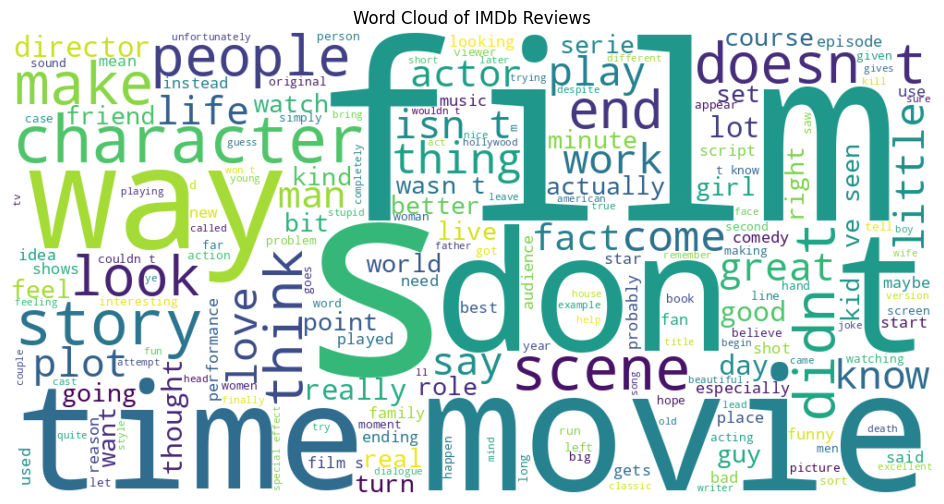

In [ ]:
print("Afifa Qureshi , 231A061")
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 9. WORD CLOUD
# ---------------------------------------------------------

clean_text_combined = " ".join(filtered_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text_combined)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of IMDb Reviews")

plt.show()



In [ ]:
print("Afifa Qureshi , 231A061")
# ---------------------------------------------------------
# 10. BIGRAM ANALYSIS
# ---------------------------------------------------------

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

# Fixed: Changed "clean_review" to "clean_text"
bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text"]
)

bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
})
bigram_df = bigram_df.sort_values(
    "Frequency",
    ascending=False
)

print("\nTop Bigrams:")
print(bigram_df)

Afifa Qureshi , 231A061

Top Bigrams:
             Bigram  Frequency
15          ve seen       4168
14  special effects       2250
0          don know       2202
6        low budget       1824
5        looks like       1679
18         year old       1601
8        movie just       1543
16       waste time       1526
2        good movie       1520
13           sci fi       1393
17      watch movie       1379
10         new york       1317
4         look like       1313
1         don think       1305
19        years ago       1256
12        real life       1240
3       high school       1164
7    main character       1140
11      pretty good       1120
9        movie like       1095


In [ ]:
print("Afifa Qureshi , 231A061")

In [ ]:
print("Afifa Qureshi , 231A061")